# 07_results_visualization_comparison

This notebook reads the final Part 1 and Part 2 solution exports and regenerates the figures used in the written report.

Main tasks:
1. load the benchmark and realistic solution tables
2. build compact comparison summaries
3. regenerate the report figures
4. verify that the exported figure files are current


In [1]:
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display


In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)


## Project paths

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

IDEAL_SOLUTIONS_DIR = PROJECT_ROOT / 'results' / 'solutions'
REALISTIC_SOLUTIONS_DIR = PROJECT_ROOT / 'results' / 'realistic' / 'solutions'
REPORT_FIG_DIR = PROJECT_ROOT / 'report' / 'figures'

REPORT_FIG_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('IDEAL_SOLUTIONS_DIR:', IDEAL_SOLUTIONS_DIR)
print('REALISTIC_SOLUTIONS_DIR:', REALISTIC_SOLUTIONS_DIR)
print('REPORT_FIG_DIR:', REPORT_FIG_DIR)


PROJECT_ROOT: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project
IDEAL_SOLUTIONS_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/results/solutions
REALISTIC_SOLUTIONS_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/results/realistic/solutions
REPORT_FIG_DIR: /Users/alexandresepulvedadedietrich/Documents/School/Columbia/Spring_2026/Optimization/group_project/report/figures


In [4]:
required_files = [
    IDEAL_SOLUTIONS_DIR / 'objective_breakdown_ideal.csv',
    IDEAL_SOLUTIONS_DIR / 'summary_stats_ideal.csv',
    IDEAL_SOLUTIONS_DIR / 'zipcode_solution_ideal.csv',
    IDEAL_SOLUTIONS_DIR / 'new_build_solution_ideal.csv',
    REALISTIC_SOLUTIONS_DIR / 'objective_breakdown_realistic.csv',
    REALISTIC_SOLUTIONS_DIR / 'summary_stats_realistic.csv',
    REALISTIC_SOLUTIONS_DIR / 'zipcode_solution_realistic.csv',
    REALISTIC_SOLUTIONS_DIR / 'build_size_summary_realistic.csv',
]

missing = [str(p) for p in required_files if not p.exists()]

for path in required_files:
    print(path.name, 'exists ->', path.exists())

if missing:
    raise FileNotFoundError(f'Missing required files: {missing}')


objective_breakdown_ideal.csv exists -> True
summary_stats_ideal.csv exists -> True
zipcode_solution_ideal.csv exists -> True
new_build_solution_ideal.csv exists -> True
objective_breakdown_realistic.csv exists -> True
summary_stats_realistic.csv exists -> True
zipcode_solution_realistic.csv exists -> True
build_size_summary_realistic.csv exists -> True


## Load solution outputs

In [5]:
ideal_objective = pd.read_csv(IDEAL_SOLUTIONS_DIR / 'objective_breakdown_ideal.csv')
ideal_summary = pd.read_csv(IDEAL_SOLUTIONS_DIR / 'summary_stats_ideal.csv')
ideal_zip = pd.read_csv(IDEAL_SOLUTIONS_DIR / 'zipcode_solution_ideal.csv')
ideal_new_build = pd.read_csv(IDEAL_SOLUTIONS_DIR / 'new_build_solution_ideal.csv')

real_objective = pd.read_csv(REALISTIC_SOLUTIONS_DIR / 'objective_breakdown_realistic.csv')
real_summary = pd.read_csv(REALISTIC_SOLUTIONS_DIR / 'summary_stats_realistic.csv')
real_zip = pd.read_csv(REALISTIC_SOLUTIONS_DIR / 'zipcode_solution_realistic.csv')
real_build_size = pd.read_csv(REALISTIC_SOLUTIONS_DIR / 'build_size_summary_realistic.csv')


In [6]:
print('ideal_objective:', ideal_objective.shape)
display(ideal_objective)

print('ideal_summary:', ideal_summary.shape)
display(ideal_summary)

print('real_objective:', real_objective.shape)
display(real_objective)

print('real_summary:', real_summary.shape)
display(real_summary)


ideal_objective: (4, 2)


,component,value
0,expansion_cost,5.471684e+07
1,new_build_cost,4.418000e+07
2,under5_equipment_cost,2.777210e+07
3,total_objective,1.266689e+08


ideal_summary: (8, 2)


,metric,value
0,total_added_expansion_slots,206364.0
1,total_added_under5_expansion_slots,202938.0
2,total_new_facilities_built,386.0
3,total_added_newbuild_slots,152900.0
4,total_added_under5_newbuild_slots,74783.0
5,facilities_in_high_cost_regime,135.0
6,zipcodes_meeting_all_requirements_after,311.0
7,zipcodes_not_meeting_all_requirements_after,0.0


real_objective: (4, 2)


,component,value
0,expansion_cost,9.381107e+06
1,new_build_cost,1.468100e+08
2,under5_equipment_cost,2.777210e+07
3,total_objective,1.839632e+08


real_summary: (14, 2)


,metric,value
0,n_expanded_facilities,1126.0
1,total_expansion_slots,25108.0
2,total_expansion_under5_slots,25067.0
3,n_new_facilities,1284.0
4,total_new_capacity,507700.0
5,total_new_under5_capacity,252654.0
6,n_new_small_facilities,13.0
7,n_new_medium_facilities,10.0
8,n_new_large_facilities,1261.0
9,zipcodes_with_new_facilities,180.0


## Helper functions

In [7]:
def metric_map(df):
    return dict(zip(df['metric'], df['value']))


def component_map(df):
    return dict(zip(df['component'], df['value']))


def annotate_bars(ax, bars, fmt='{:.1f}', suffix=''):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            fmt.format(height) + suffix,
            ha='center',
            va='bottom',
            fontsize=9,
        )


## Build report summary tables

Before plotting, the notebook assembles the benchmark and realistic summary values into small tables that can be checked against the report narrative.


In [8]:
ideal_summary_map = metric_map(ideal_summary)
real_summary_map = metric_map(real_summary)
ideal_cost_map = component_map(ideal_objective)
real_cost_map = component_map(real_objective)

ideal_build_mix = (
    ideal_new_build.groupby('size', as_index=False)['num_new_facilities']
    .sum()
    .rename(columns={'num_new_facilities': 'n_new_facilities'})
)

comparison_summary = pd.DataFrame([
    {
        'metric': 'total_cost',
        'part1': ideal_cost_map['total_objective'],
        'part2': real_cost_map['total_objective'],
    },
    {
        'metric': 'expansion_slots',
        'part1': ideal_summary_map['total_added_expansion_slots'],
        'part2': real_summary_map['total_expansion_slots'],
    },
    {
        'metric': 'new_build_slots',
        'part1': ideal_summary_map['total_added_newbuild_slots'],
        'part2': real_summary_map['total_new_capacity'],
    },
    {
        'metric': 'new_facilities',
        'part1': ideal_summary_map['total_new_facilities_built'],
        'part2': real_summary_map['n_new_facilities'],
    },
])
comparison_summary['change'] = comparison_summary['part2'] - comparison_summary['part1']

print('Ideal build mix:')
display(ideal_build_mix)

print('Part 1 vs Part 2 comparison summary:')
display(comparison_summary)


Ideal build mix:


,size,n_new_facilities
0,large,380.0
1,medium,3.0
2,small,3.0


Part 1 vs Part 2 comparison summary:


,metric,part1,part2,change
0,total_cost,1.266689e+08,1.839632e+08,5.729427e+07
1,expansion_slots,2.063640e+05,2.510800e+04,-1.812560e+05
2,new_build_slots,1.529000e+05,5.077000e+05,3.548000e+05
3,new_facilities,3.860000e+02,1.284000e+03,8.980000e+02


## Figure 1: Part 1 cost breakdown

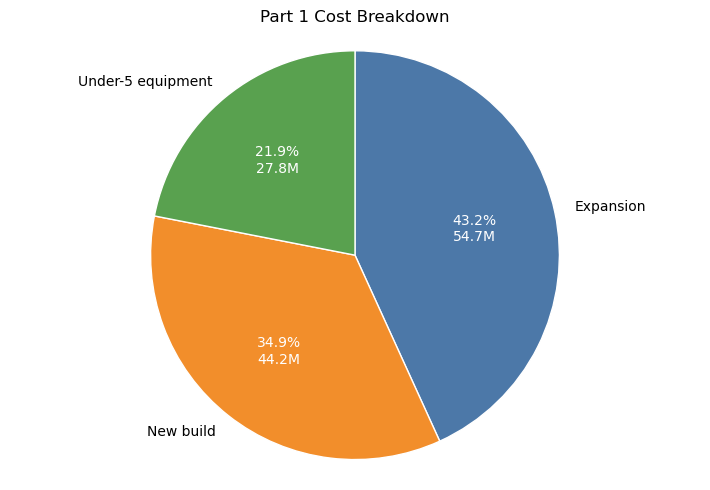

In [9]:
labels = ['Expansion', 'New build', 'Under-5 equipment']
values = np.array([
    ideal_cost_map['expansion_cost'],
    ideal_cost_map['new_build_cost'],
    ideal_cost_map['under5_equipment_cost'],
]) / 1_000_000
colors = ['#4C78A8', '#F28E2B', '#59A14F']

def autopct_millions(pct):
    value = pct * values.sum() / 100.0
    return f'{pct:.1f}%\n{value:.1f}M'

fig, ax = plt.subplots(figsize=(7.2, 5.0))
wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct=autopct_millions,
    startangle=90,
    counterclock=False,
    wedgeprops={'linewidth': 1.0, 'edgecolor': 'white'},
    textprops={'fontsize': 10},
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
ax.set_title('Part 1 Cost Breakdown')
ax.axis('equal')
fig.tight_layout()
fig.savefig(REPORT_FIG_DIR / 'ideal_cost_breakdown.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)


## Figure 2: Part 1 vs Part 2 overview

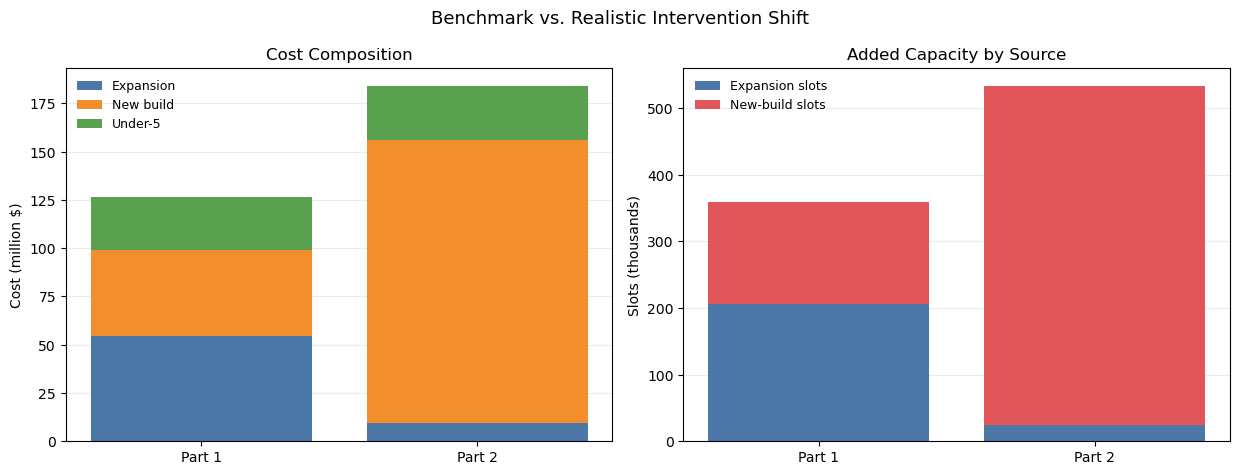

In [10]:
parts = ['Part 1', 'Part 2']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

cost_labels = ['Expansion', 'New build', 'Under-5']
cost_colors = ['#4C78A8', '#F28E2B', '#59A14F']
cost_data = np.array([
    [
        ideal_cost_map['expansion_cost'],
        ideal_cost_map['new_build_cost'],
        ideal_cost_map['under5_equipment_cost'],
    ],
    [
        real_cost_map['expansion_cost'],
        real_cost_map['new_build_cost'],
        real_cost_map['under5_equipment_cost'],
    ],
]) / 1_000_000

bottom = np.zeros(len(parts))
for idx, label in enumerate(cost_labels):
    axes[0].bar(parts, cost_data[:, idx], bottom=bottom, color=cost_colors[idx], label=label)
    bottom += cost_data[:, idx]
axes[0].set_title('Cost Composition')
axes[0].set_ylabel('Cost (million $)')
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_axisbelow(True)
axes[0].legend(frameon=False, fontsize=9)

slot_labels = ['Expansion slots', 'New-build slots']
slot_colors = ['#4C78A8', '#E15759']
slot_data = np.array([
    [
        ideal_summary_map['total_added_expansion_slots'],
        ideal_summary_map['total_added_newbuild_slots'],
    ],
    [
        real_summary_map['total_expansion_slots'],
        real_summary_map['total_new_capacity'],
    ],
]) / 1_000

bottom = np.zeros(len(parts))
for idx, label in enumerate(slot_labels):
    axes[1].bar(parts, slot_data[:, idx], bottom=bottom, color=slot_colors[idx], label=label)
    bottom += slot_data[:, idx]
axes[1].set_title('Added Capacity by Source')
axes[1].set_ylabel('Slots (thousands)')
axes[1].grid(axis='y', alpha=0.25)
axes[1].set_axisbelow(True)
axes[1].legend(frameon=False, fontsize=9)

fig.suptitle('Benchmark vs. Realistic Intervention Shift', fontsize=13)
fig.tight_layout()
fig.savefig(REPORT_FIG_DIR / 'part_comparison_overview.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)


## Figure 3: Realistic model size mix and top ZIP codes

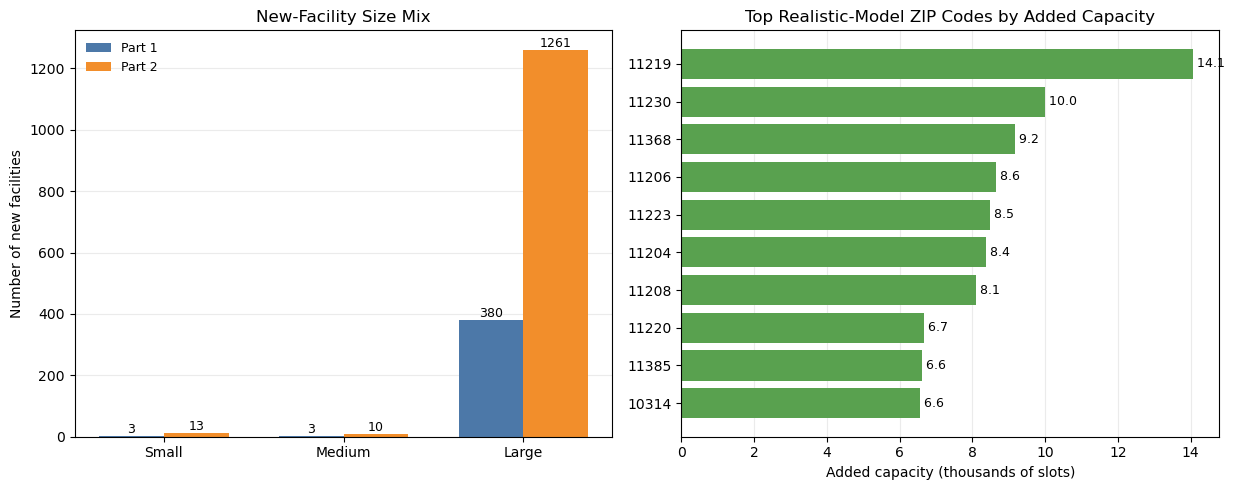

In [11]:
size_order = ['small', 'medium', 'large']
ideal_build_map = ideal_build_mix.set_index('size')['n_new_facilities'].to_dict()
real_build_map = real_build_size.set_index('size')['n_new_facilities'].to_dict()

ideal_vals = [float(ideal_build_map.get(size, 0.0)) for size in size_order]
real_vals = [float(real_build_map.get(size, 0.0)) for size in size_order]

real_zip_plot = real_zip.copy()
real_zip_plot['total_added_capacity'] = real_zip_plot['expanded_total'] + real_zip_plot['new_total_capacity']
top_zip = real_zip_plot.sort_values('total_added_capacity', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

x = np.arange(len(size_order))
width = 0.36
bars1 = axes[0].bar(x - width / 2, ideal_vals, width, label='Part 1', color='#4C78A8')
bars2 = axes[0].bar(x + width / 2, real_vals, width, label='Part 2', color='#F28E2B')
annotate_bars(axes[0], bars1, fmt='{:.0f}')
annotate_bars(axes[0], bars2, fmt='{:.0f}')
axes[0].set_xticks(x, [s.title() for s in size_order])
axes[0].set_ylabel('Number of new facilities')
axes[0].set_title('New-Facility Size Mix')
axes[0].legend(frameon=False, fontsize=9)
axes[0].grid(axis='y', alpha=0.25)
axes[0].set_axisbelow(True)

bars = axes[1].barh(top_zip['zipcode'].astype(str), top_zip['total_added_capacity'] / 1_000, color='#59A14F')
axes[1].invert_yaxis()
axes[1].set_xlabel('Added capacity (thousands of slots)')
axes[1].set_title('Top Realistic-Model ZIP Codes by Added Capacity')
axes[1].grid(axis='x', alpha=0.25)
axes[1].set_axisbelow(True)
for bar in bars:
    width_val = bar.get_width()
    axes[1].text(width_val, bar.get_y() + bar.get_height() / 2, f' {width_val:.1f}', va='center', ha='left', fontsize=9)

fig.tight_layout()
fig.savefig(REPORT_FIG_DIR / 'realistic_mix_and_zipcodes.png', dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)


## Export check

The final cell confirms that the figure files written to `report/figures` match the current notebook run.


In [12]:
for name in [
    'ideal_cost_breakdown.png',
    'part_comparison_overview.png',
    'realistic_mix_and_zipcodes.png',
]:
    path = REPORT_FIG_DIR / name
    print(name, 'exists ->', path.exists(), 'size_bytes ->', path.stat().st_size if path.exists() else None)


ideal_cost_breakdown.png exists -> True size_bytes -> 78785
part_comparison_overview.png exists -> True size_bytes -> 96766
realistic_mix_and_zipcodes.png exists -> True size_bytes -> 127393
